Mean Squared Error: 950.3134403744414
R2 Score: 0.6492717272790235


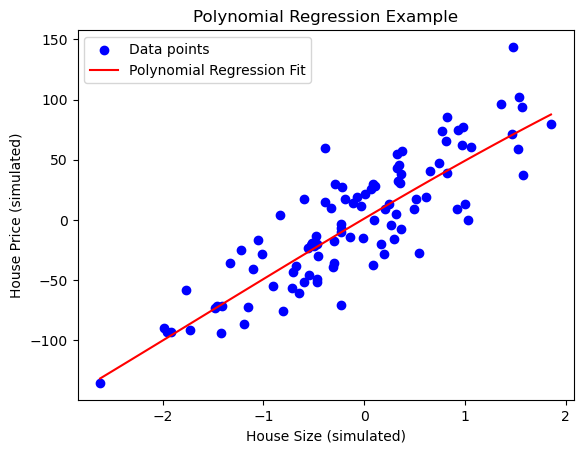

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

# Generate a synthetic dataset (house size vs price)
X, y = make_regression(n_samples=100, n_features=1, noise=30, random_state=42)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transform features to polynomial features (degree 2 or 3)
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Fit Linear Regression on polynomial features
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict
y_pred = model.predict(X_test_poly)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Plot results
plt.scatter(X, y, color='blue', label='Data points')
X_plot = np.linspace(min(X), max(X), 100).reshape(-1,1)
y_plot = model.predict(poly.transform(X_plot))
plt.plot(X_plot, y_plot, color='red', label='Polynomial Regression Fit')
plt.xlabel("House Size (simulated)")
plt.ylabel("House Price (simulated)")
plt.title("Polynomial Regression Example")
plt.legend()
plt.show()
